In [3]:
!pip install numpy pandas plotly matplotlib seaborn missingno folium dash dash_core_components dash_html_components

Importation des librairies et préparation de l'affichage

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tarfile
import os
from functools import reduce

# Configuring display settings
plt.rcParams['figure.figsize'] = (12, 9)
sns.set()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings("ignore", category=FutureWarning)


Visualisation et exploration des données

In [5]:

employee_survey_data_file_path = os.path.join('employee_survey_data.csv')
general_data_file_path = os.path.join('general_data.csv')
manager_survey_data_file_path = os.path.join('manager_survey_data.csv')
in_time_data_file_path = os.path.join('in_time.csv')
out_time_data_file_path = os.path.join('out_time.csv')
# Load the dataset
employee_survey_data = pd.read_csv(employee_survey_data_file_path)
general_data = pd.read_csv(general_data_file_path)
manager_survey_data = pd.read_csv(manager_survey_data_file_path)
in_time_data = pd.read_csv(in_time_data_file_path)
out_time_data = pd.read_csv(out_time_data_file_path)

Compréhension du dataset employee_data

In [6]:
employee_survey_data.head()
employee_survey_data.info()
employee_survey_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
count,4410.00,4385.00,4390.00,4372.00
mean,2205.50,2.72,2.73,2.76
std,1273.20,1.09,1.10,0.71
min,1.00,1.00,1.00,1.00
25%,1103.25,2.00,2.00,2.00
50%,2205.50,3.00,3.00,3.00
75%,3307.75,4.00,4.00,3.00
max,4410.00,4.00,4.00,4.00


Compréhension du dataset general_data

In [7]:
general_data.head()
general_data.info()
general_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4391.00,4410.00,4410.00,4410.00,4401.00,4410.00,4410.00,4410.00,4410.00
mean,36.92,9.19,2.91,1.00,2205.50,2.06,65029.31,2.69,15.21,8.00,0.79,11.28,2.80,7.01,2.19,4.12
std,9.13,8.11,1.02,0.00,1273.20,1.11,47068.89,2.50,3.66,0.00,0.85,7.78,1.29,6.13,3.22,3.57
min,18.00,1.00,1.00,1.00,1.00,1.00,10090.00,0.00,11.00,8.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,2.00,2.00,1.00,1103.25,1.00,29110.00,1.00,12.00,8.00,0.00,6.00,2.00,3.00,0.00,2.00
50%,36.00,7.00,3.00,1.00,2205.50,2.00,49190.00,2.00,14.00,8.00,1.00,10.00,3.00,5.00,1.00,3.00
75%,43.00,14.00,4.00,1.00,3307.75,3.00,83800.00,4.00,18.00,8.00,1.00,15.00,3.00,9.00,3.00,7.00
max,60.00,29.00,5.00,1.00,4410.00,5.00,199990.00,9.00,25.00,8.00,3.00,40.00,6.00,40.00,15.00,17.00


Compréhension du dataset manager_survey_data

In [8]:
manager_survey_data.head()
manager_survey_data.info()
manager_survey_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


,EmployeeID,JobInvolvement,PerformanceRating
count,4410.00,4410.00,4410.00
mean,2205.50,2.73,3.15
std,1273.20,0.71,0.36
min,1.00,1.00,3.00
25%,1103.25,2.00,3.00
50%,2205.50,3.00,3.00
75%,3307.75,3.00,3.00
max,4410.00,4.00,4.00


Objet de l'étude : Le salarié a-t-il quiité l'entreprise durant l'année 2016 ?

In [9]:
general_data['Attrition'].value_counts()

Attrition
No     3699
Yes     711
Name: count, dtype: int64

Nettoyage des valeurs manquantes de employee_survey_data

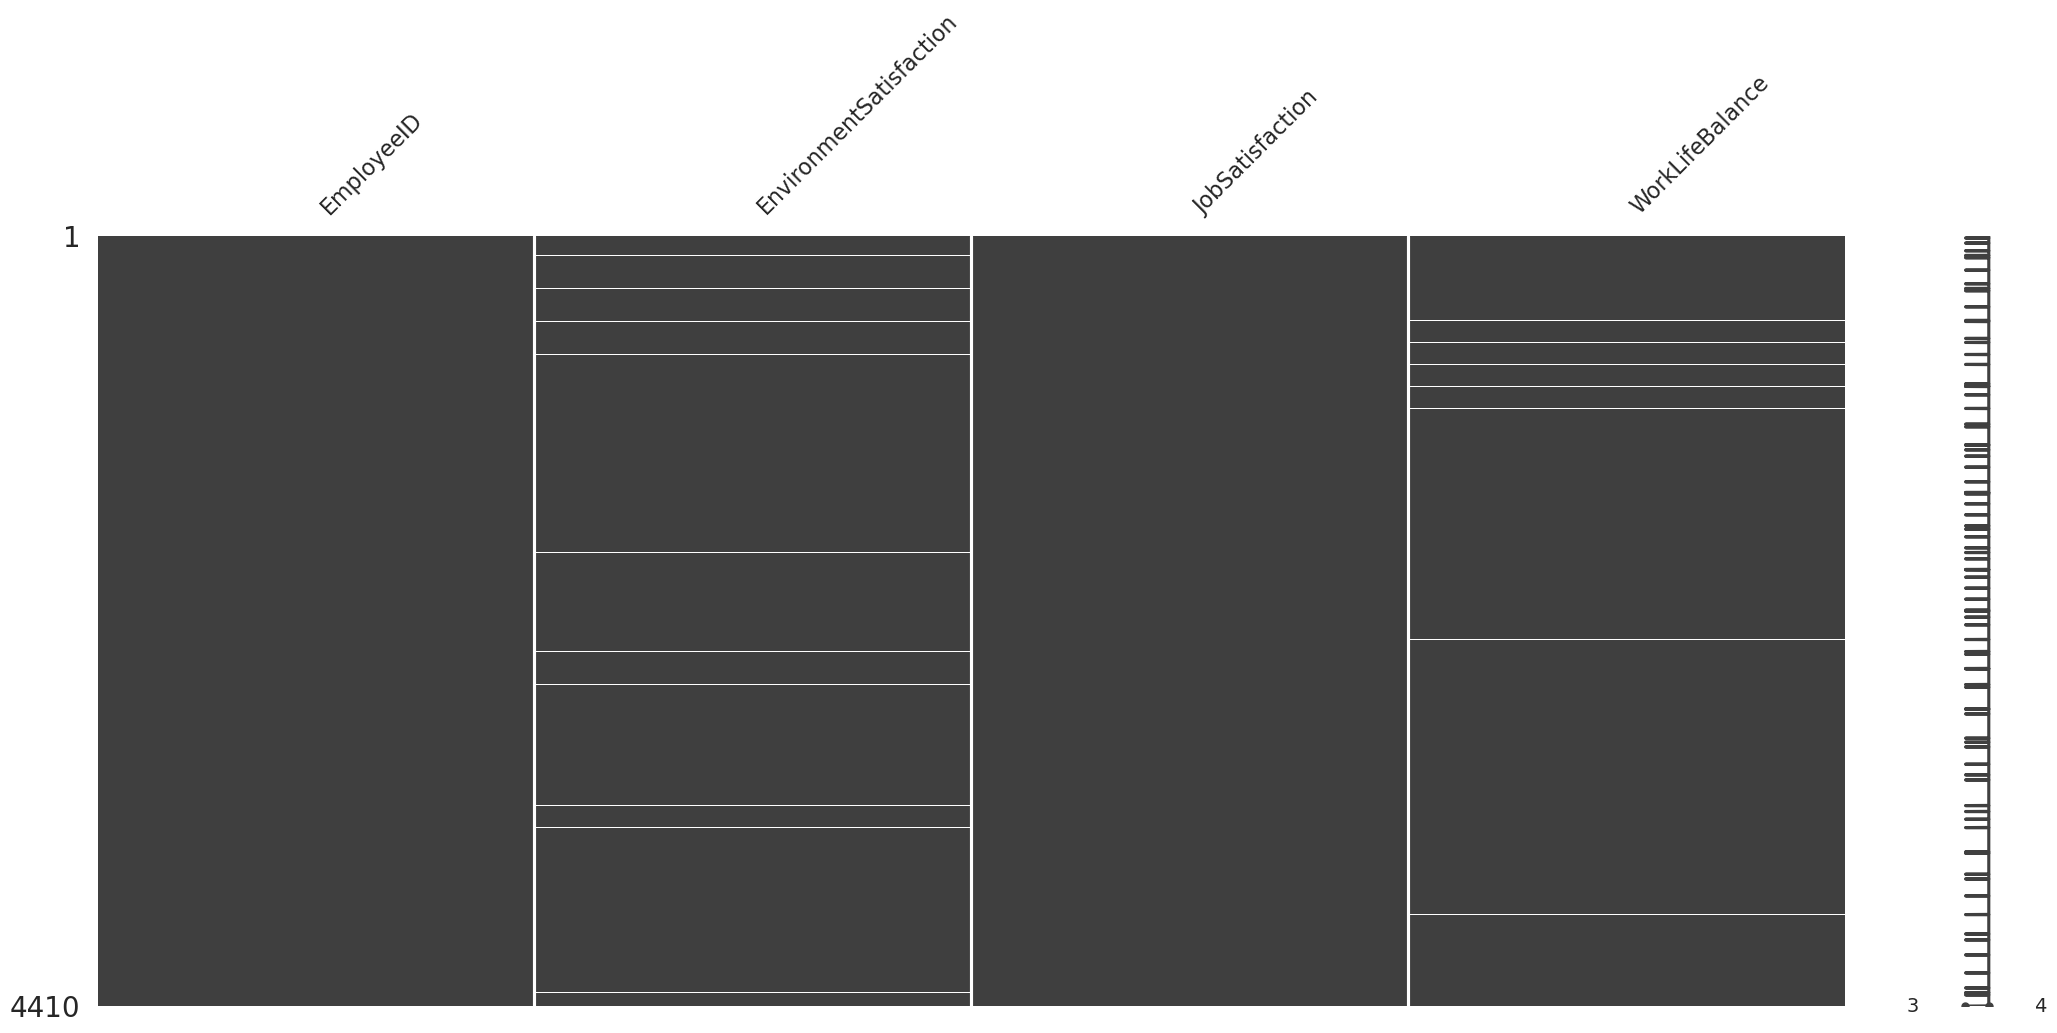

EmployeeID                 0
EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
dtype: int64

In [10]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(employee_survey_data)
plt.show()

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = employee_survey_data.select_dtypes(include=['float64', 'int64']).columns
employee_survey_data[numerical_columns] = employee_survey_data[numerical_columns].fillna(employee_survey_data[numerical_columns].median())

# For categorical columns, use mode imputation
categorical_columns = employee_survey_data.select_dtypes(include=['object']).columns

# Verify that there are no more missing values
employee_survey_data.isnull().sum()


Traitement des valeurs manquantes de general_data

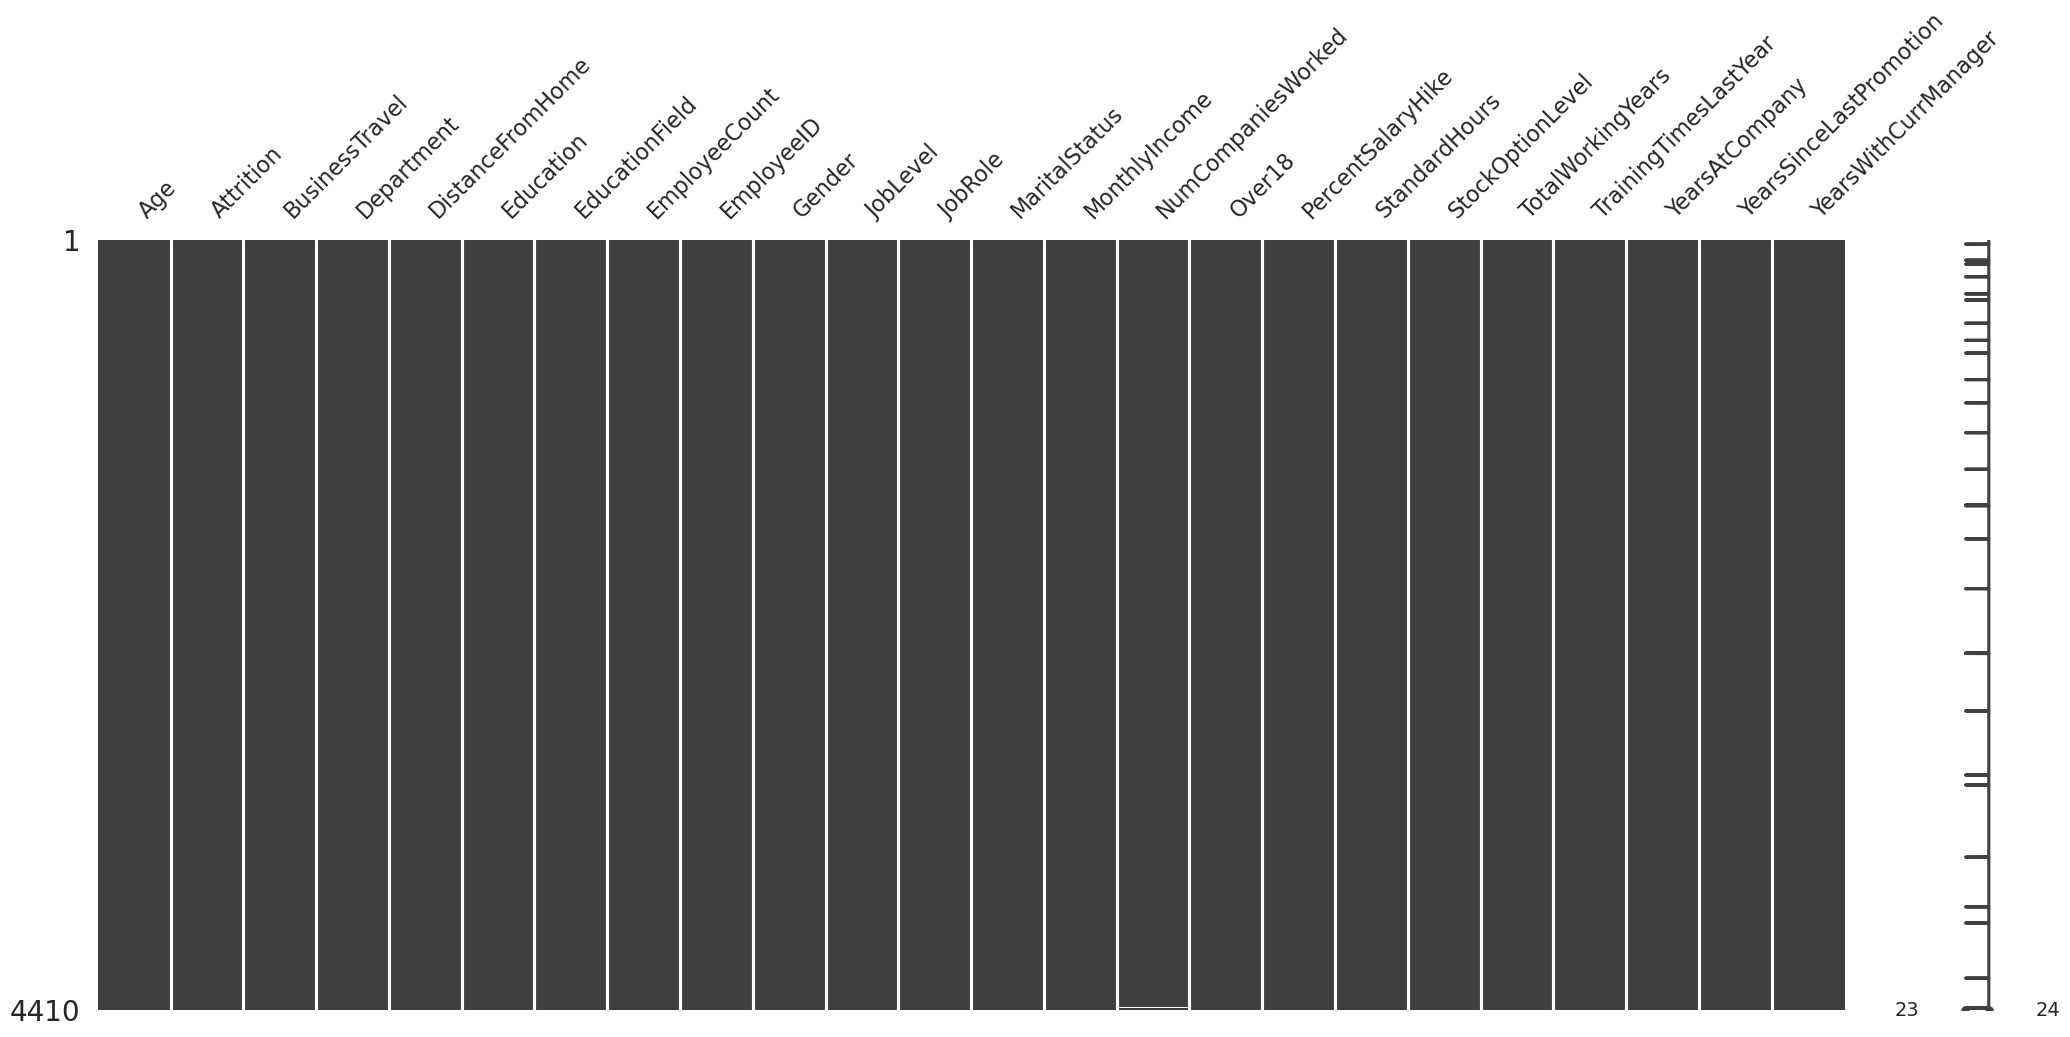

Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
Over18                     0
PercentSalaryHike          0
StandardHours              0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

In [11]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(general_data)
plt.show()

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = general_data.select_dtypes(include=['float64', 'int64']).columns
general_data[numerical_columns] = general_data[numerical_columns].fillna(general_data[numerical_columns].median())

# For categorical columns, use mode imputation
categorical_columns = general_data.select_dtypes(include=['object']).columns
general_data[categorical_columns] = general_data[categorical_columns].fillna(general_data[categorical_columns].mode().iloc[0])

# Verify that there are no more missing values
general_data.isnull().sum()


Traitement des valeurs manquantes de manager_survey_data

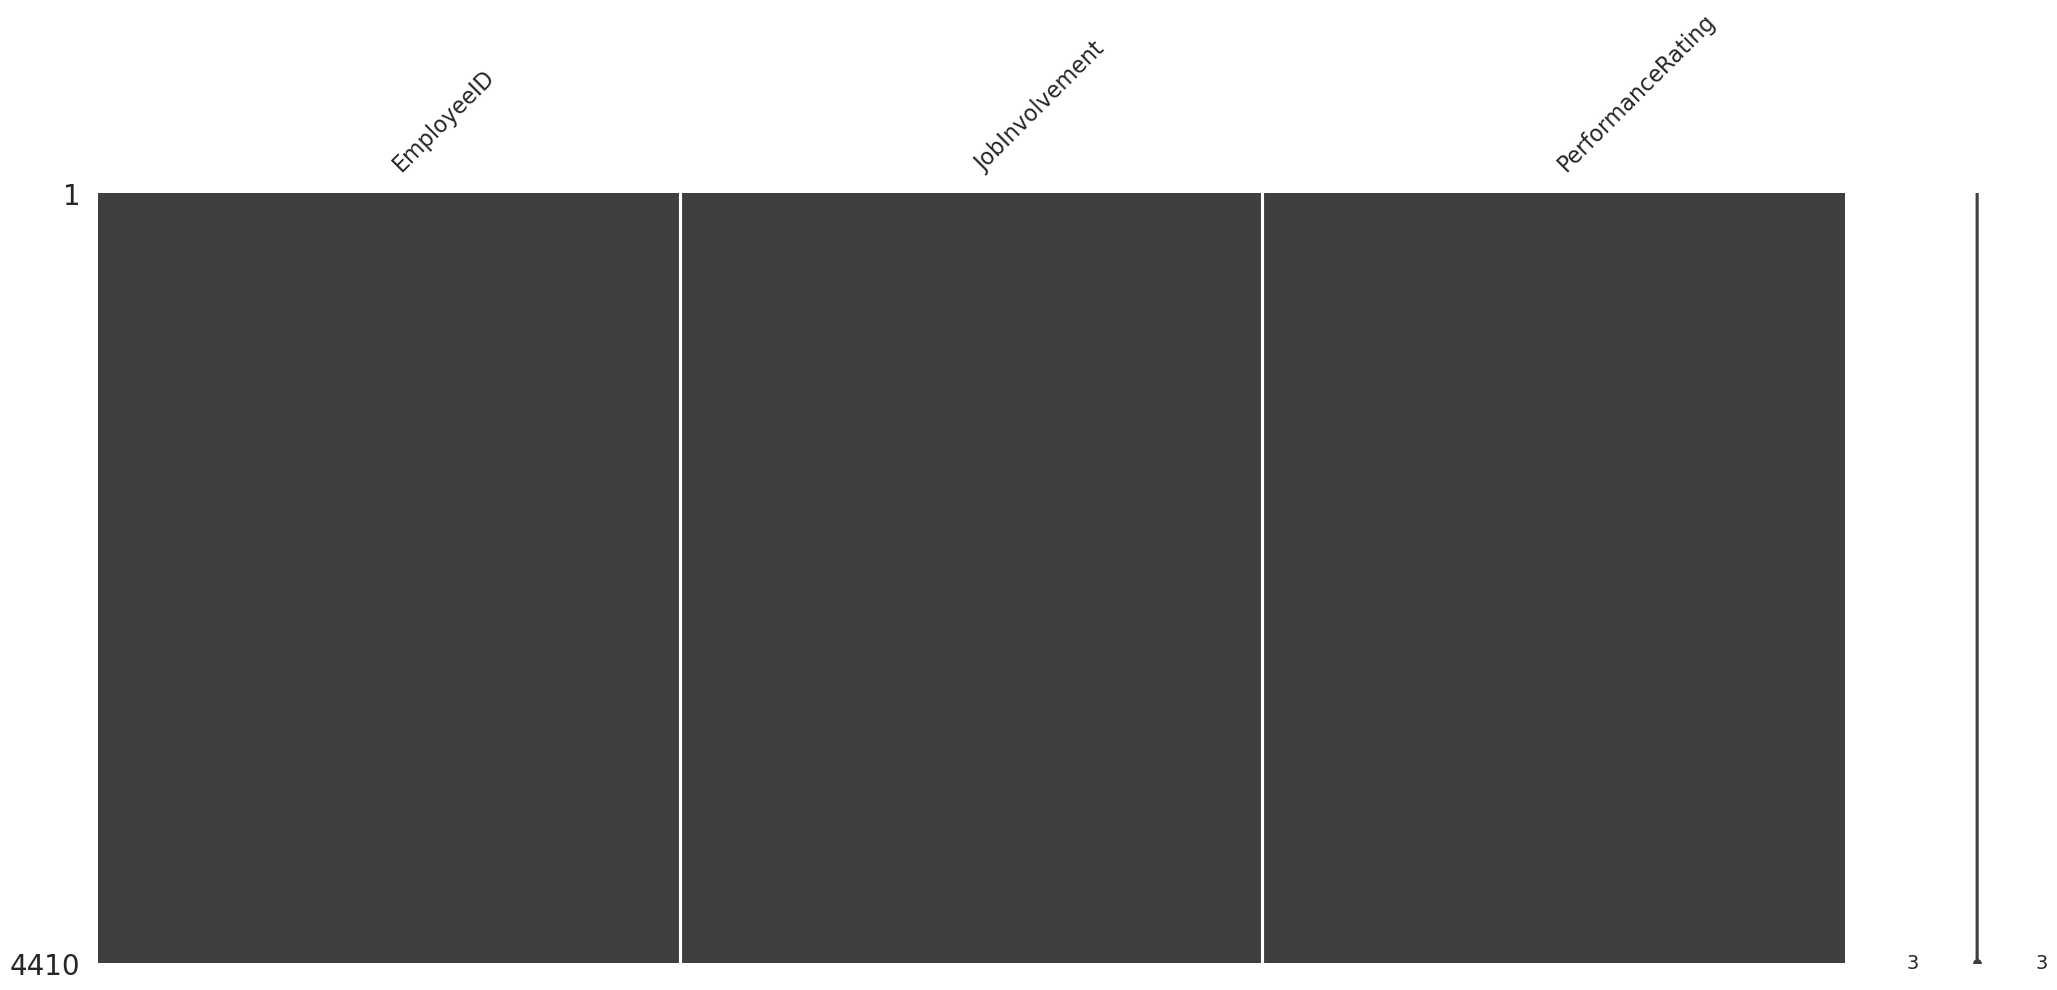

EmployeeID           0
JobInvolvement       0
PerformanceRating    0
dtype: int64

In [12]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(manager_survey_data)
plt.show()

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = manager_survey_data.select_dtypes(include=['float64', 'int64']).columns
manager_survey_data[numerical_columns] = manager_survey_data[numerical_columns].fillna(manager_survey_data[numerical_columns].median())

# Verify that there are no more missing values
manager_survey_data.isnull().sum()


Traitement du dataset in_time_data et out_time_data

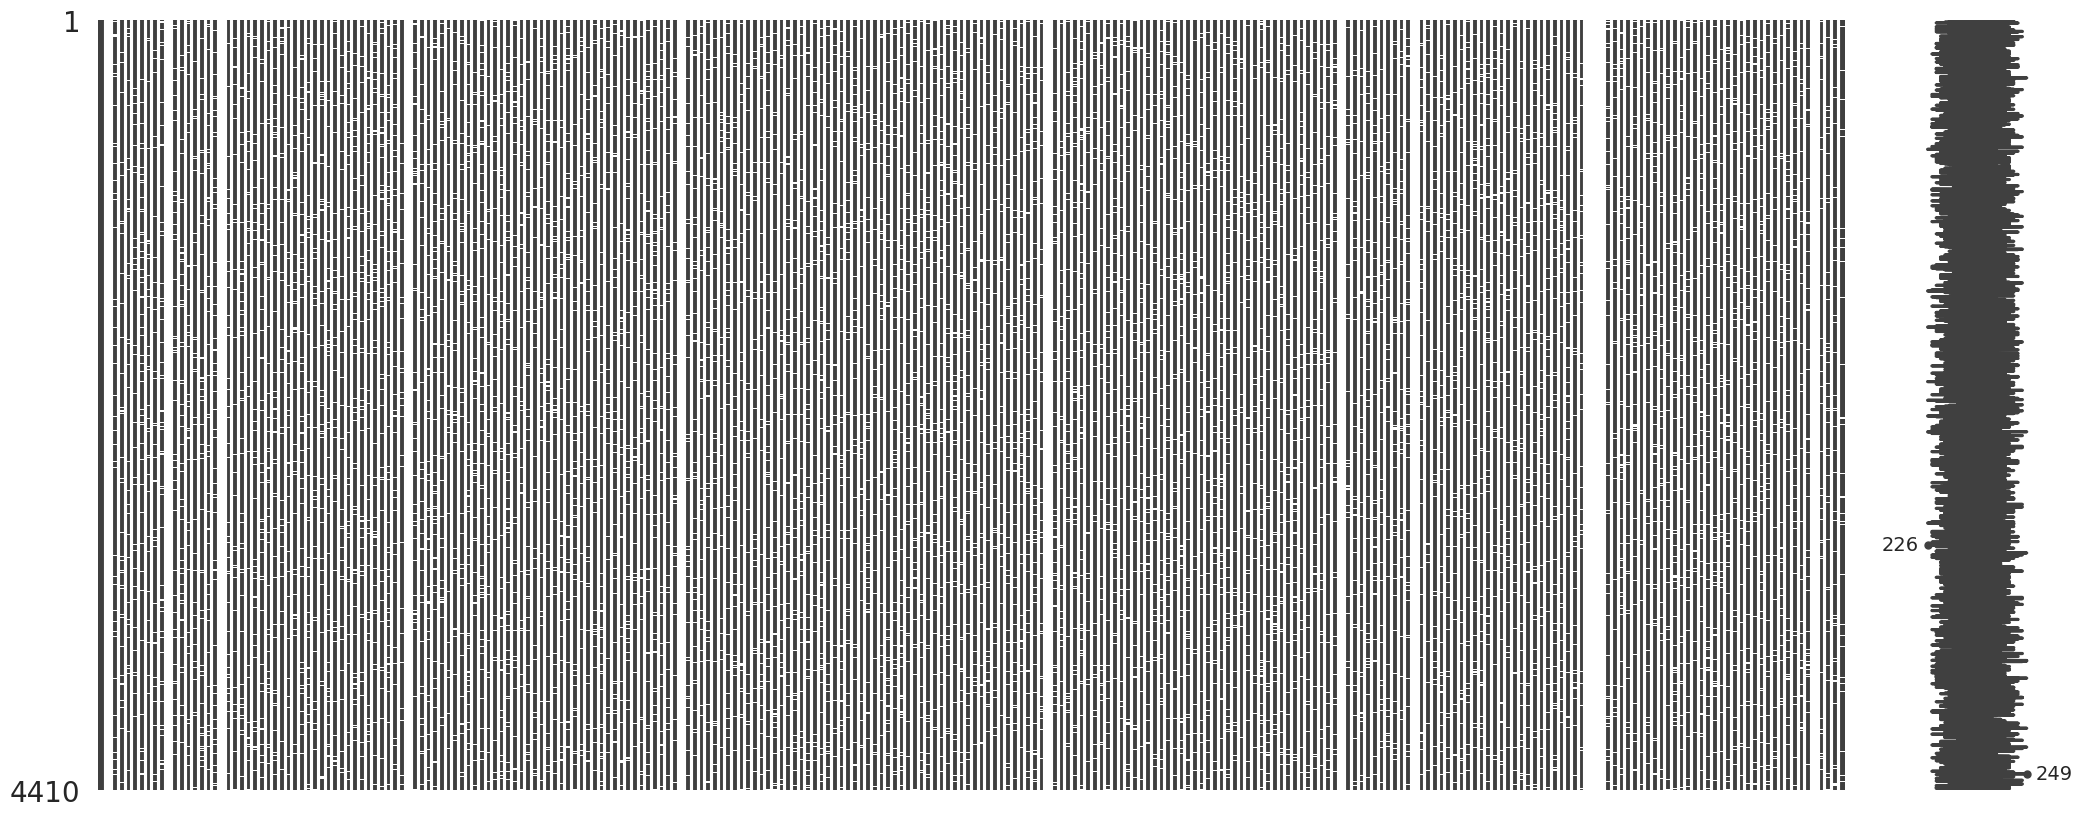

EmployeeID       0
2015-01-01    4410
2015-01-02       0
2015-01-05       0
2015-01-06       0
              ... 
2015-12-25    4410
2015-12-28       0
2015-12-29       0
2015-12-30       0
2015-12-31       0
Length: 262, dtype: int64

In [13]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(in_time_data)
plt.show()

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = in_time_data.select_dtypes(include=['float64', 'int64']).columns
in_time_data[numerical_columns] = in_time_data[numerical_columns].fillna(in_time_data[numerical_columns].median())

# For categorical columns, use mode imputation
categorical_columns = in_time_data.select_dtypes(include=['object']).columns
in_time_data[categorical_columns] = in_time_data[categorical_columns].fillna(in_time_data[categorical_columns].mode().iloc[0])

# Verify that there are no more missing values
in_time_data.isnull().sum()


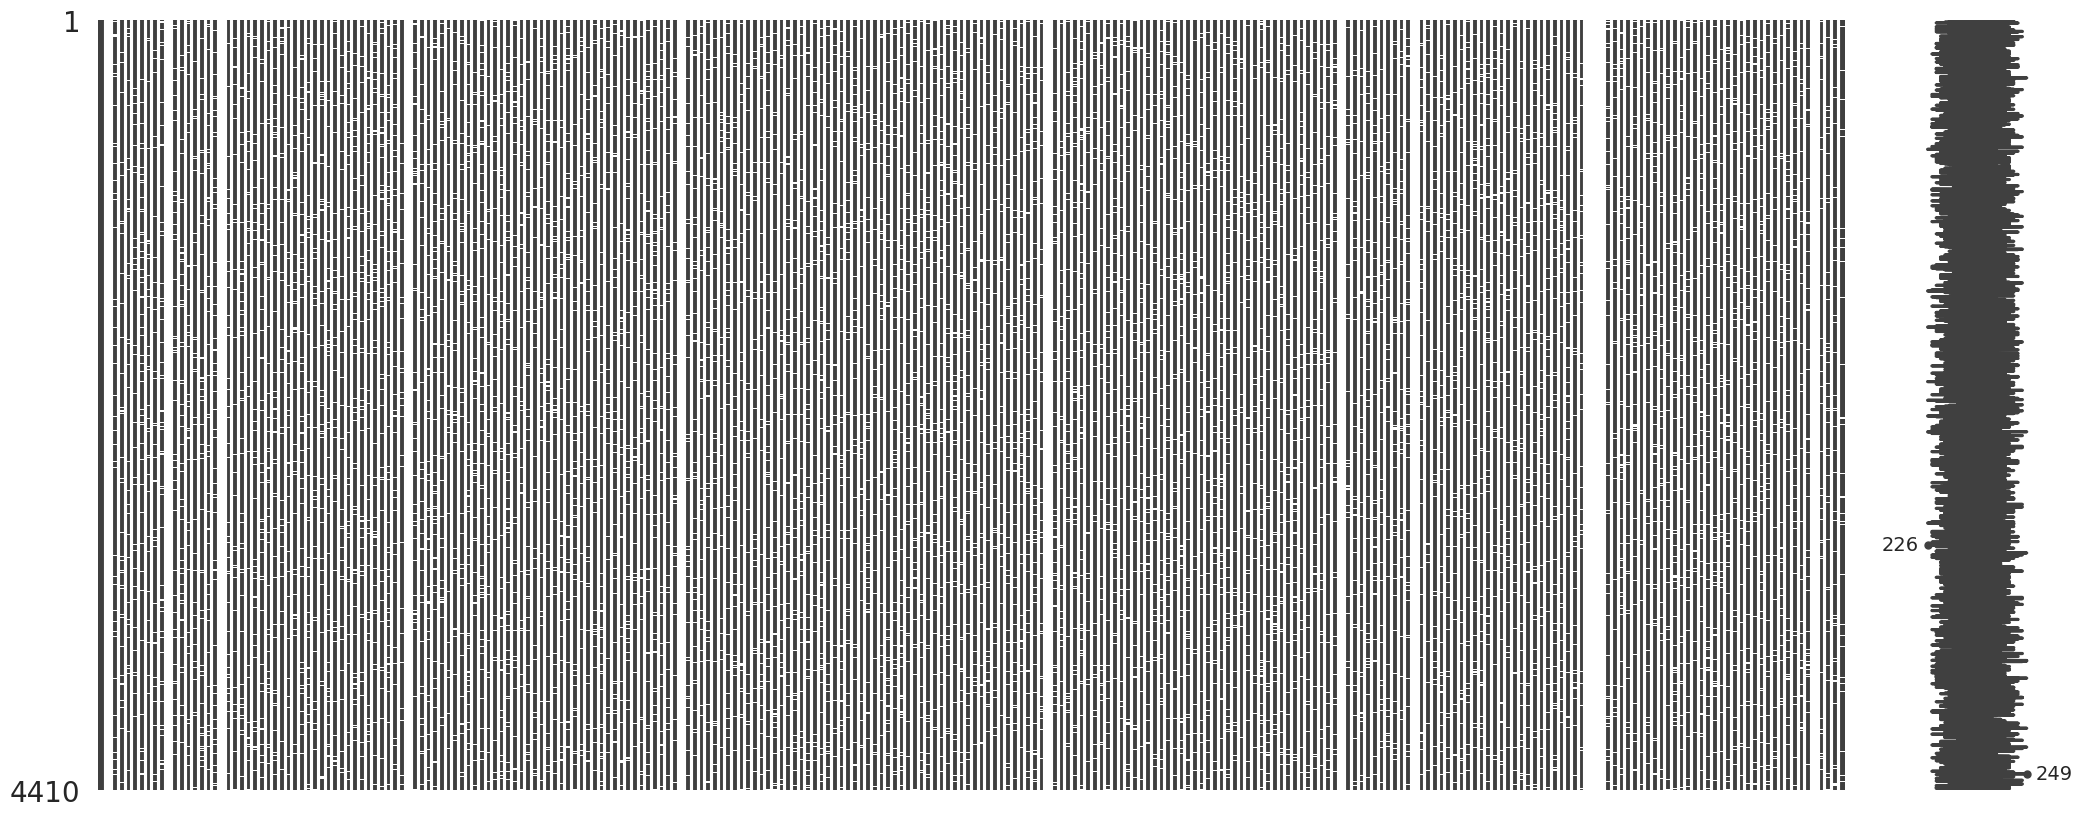

EmployeeID       0
2015-01-01    4410
2015-01-02       0
2015-01-05       0
2015-01-06       0
              ... 
2015-12-25    4410
2015-12-28       0
2015-12-29       0
2015-12-30       0
2015-12-31       0
Length: 262, dtype: int64

In [14]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data
msno.matrix(out_time_data)
plt.show()

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = out_time_data.select_dtypes(include=['float64', 'int64']).columns
out_time_data[numerical_columns] = out_time_data[numerical_columns].fillna(out_time_data[numerical_columns].median())

# For categorical columns, use mode imputation
categorical_columns = out_time_data.select_dtypes(include=['object']).columns
out_time_data[categorical_columns] = out_time_data[categorical_columns].fillna(out_time_data[categorical_columns].mode().iloc[0])

# Verify that there are no more missing values
out_time_data.isnull().sum()

Réduction des datasets in et out

In [15]:
# Réduction des datasets in_time_data et out_time_data en un seul dataset moyen par employé
df_in = in_time_data.copy()
df_out = out_time_data.copy()

# Colonnes de dates (toutes sauf EmployeeID)
date_cols = [c for c in df_in.columns if c != 'EmployeeID']

# Passer du format large au format long
in_long = df_in.melt(id_vars='EmployeeID', value_vars=date_cols, var_name='Date', value_name='In_Time')
out_long = df_out.melt(id_vars='EmployeeID', value_vars=date_cols, var_name='Date', value_name='Out_Time')

# Fusionner in/out par employé et date
df_combined = pd.merge(in_long, out_long, on=['EmployeeID', 'Date'], how='inner')

# Convertir en datetime et supprimer les lignes invalides
df_combined['In_Time'] = pd.to_datetime(df_combined['In_Time'], errors='coerce')
df_combined['Out_Time'] = pd.to_datetime(df_combined['Out_Time'], errors='coerce')
df_combined = df_combined.dropna(subset=['In_Time', 'Out_Time'])

# Convertir les horaires en secondes depuis minuit
df_combined['In_Seconds'] = (
    df_combined['In_Time'].dt.hour * 3600
    + df_combined['In_Time'].dt.minute * 60
    + df_combined['In_Time'].dt.second
)
df_combined['Out_Seconds'] = (
    df_combined['Out_Time'].dt.hour * 3600
    + df_combined['Out_Time'].dt.minute * 60
    + df_combined['Out_Time'].dt.second
)

# Durée de travail journalière (en heures)
df_combined['Duration'] = (df_combined['Out_Time'] - df_combined['In_Time']).dt.total_seconds() / 3600

# Corriger les durées négatives (cas passage après minuit)
df_combined.loc[df_combined['Duration'] < 0, 'Duration'] += 24

# Moyennes par employé
df_final = df_combined.groupby('EmployeeID', as_index=False).agg({
    'In_Seconds': 'mean',
    'Out_Seconds': 'mean',
    'Duration': 'mean'
})

# Reconvertir les secondes moyennes en HH:MM:SS
def seconds_to_hms(seconds):
    if pd.isna(seconds):
        return None
    seconds = int(round(seconds)) % (24 * 3600)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

df_final['Mean_In_Time'] = df_final['In_Seconds'].apply(seconds_to_hms)
df_final['Mean_Out_Time'] = df_final['Out_Seconds'].apply(seconds_to_hms)

# Dataset final demandé
df_result = df_final[['EmployeeID', 'Mean_In_Time', 'Mean_Out_Time', 'Duration']].rename(
    columns={'Duration': 'Mean_Duration_Hours'}
)

print(df_result.head())

   EmployeeID Mean_In_Time Mean_Out_Time  Mean_Duration_Hours
0           1     09:59:57      17:19:55                 7.33
1           2     09:59:06      17:39:31                 7.67
2           3     10:01:17      17:01:51                 7.01
3           4     09:58:44      17:09:48                 7.18
4           5     09:59:51      17:59:13                 7.99


Jointure des datasets

In [16]:
# Jointure des datasets avec le dataset temporel réduit
datasets = [employee_survey_data, general_data, manager_survey_data, df_result]
merged_data = reduce(lambda left, right: pd.merge(left, right, on='EmployeeID', how='outer'), datasets)
merged_data.head()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,Mean_In_Time,Mean_Out_Time,Mean_Duration_Hours
0,1,3.00,4.00,2.00,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,Healthcare Representative,Married,131160,1.00,Y,11,8,0,1.00,6,1,0,0,3,3,09:59:57,17:19:55,7.33
1,2,3.00,2.00,4.00,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,Female,1,Research Scientist,Single,41890,0.00,Y,23,8,1,6.00,3,5,1,4,2,4,09:59:06,17:39:31,7.67
2,3,2.00,2.00,1.00,32,No,Travel_Frequently,Research & Development,17,4,Other,1,Male,4,Sales Executive,Married,193280,1.00,Y,15,8,3,5.00,2,5,0,3,3,3,10:01:17,17:01:51,7.01
3,4,4.00,4.00,3.00,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,Male,3,Human Resources,Married,83210,3.00,Y,11,8,3,13.00,5,8,7,5,2,3,09:58:44,17:09:48,7.18
4,5,4.00,1.00,3.00,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,Male,1,Sales Executive,Single,23420,4.00,Y,12,8,2,9.00,2,6,0,4,3,3,09:59:51,17:59:13,7.99


Analyse du dataset fusionnée

In [17]:
merged_data.info()
merged_data.describe()
merged_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4410 non-null   float64
 2   JobSatisfaction          4410 non-null   float64
 3   WorkLifeBalance          4410 non-null   float64
 4   Age                      4410 non-null   int64  
 5   Attrition                4410 non-null   object 
 6   BusinessTravel           4410 non-null   object 
 7   Department               4410 non-null   object 
 8   DistanceFromHome         4410 non-null   int64  
 9   Education                4410 non-null   int64  
 10  EducationField           4410 non-null   object 
 11  EmployeeCount            4410 non-null   int64  
 12  Gender                   4410 non-null   object 
 13  JobLevel                 4410 non-null   int64  
 14  JobRole                 

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,Mean_In_Time,Mean_Out_Time,Mean_Duration_Hours
0,1,3.00,4.00,2.00,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,Healthcare Representative,Married,131160,1.00,Y,11,8,0,1.00,6,1,0,0,3,3,09:59:57,17:19:55,7.33
1,2,3.00,2.00,4.00,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,Female,1,Research Scientist,Single,41890,0.00,Y,23,8,1,6.00,3,5,1,4,2,4,09:59:06,17:39:31,7.67
2,3,2.00,2.00,1.00,32,No,Travel_Frequently,Research & Development,17,4,Other,1,Male,4,Sales Executive,Married,193280,1.00,Y,15,8,3,5.00,2,5,0,3,3,3,10:01:17,17:01:51,7.01
3,4,4.00,4.00,3.00,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,Male,3,Human Resources,Married,83210,3.00,Y,11,8,3,13.00,5,8,7,5,2,3,09:58:44,17:09:48,7.18
4,5,4.00,1.00,3.00,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,Male,1,Sales Executive,Single,23420,4.00,Y,12,8,2,9.00,2,6,0,4,3,3,09:59:51,17:59:13,7.99


Matrice de corrélation et pairplot

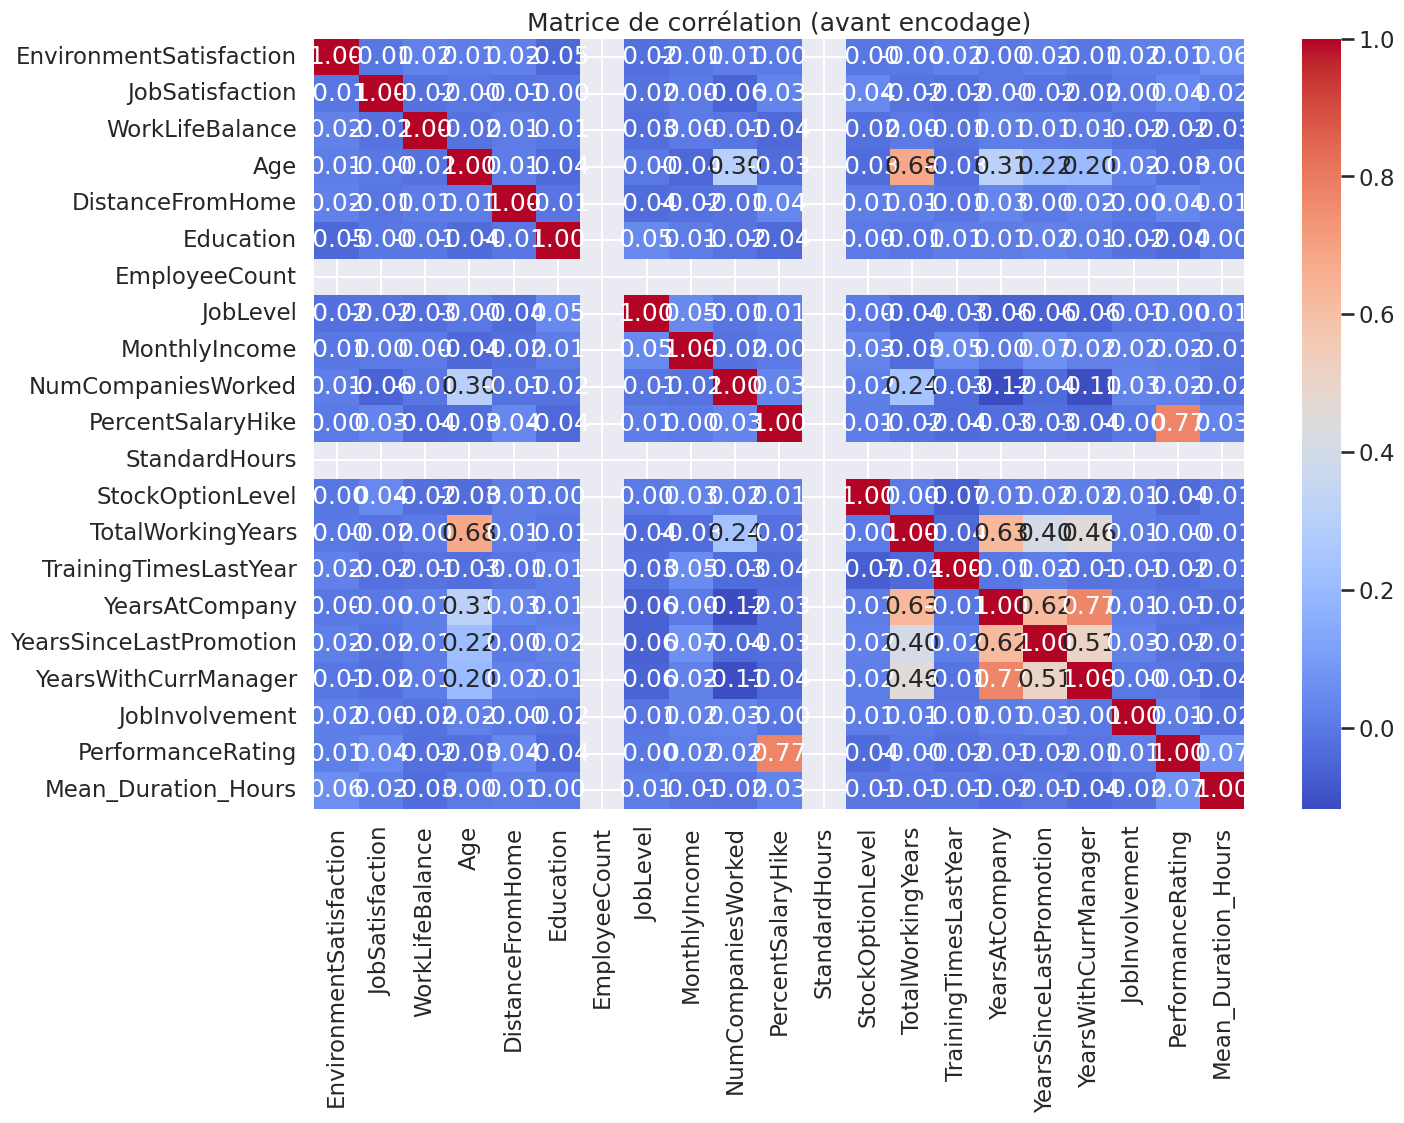

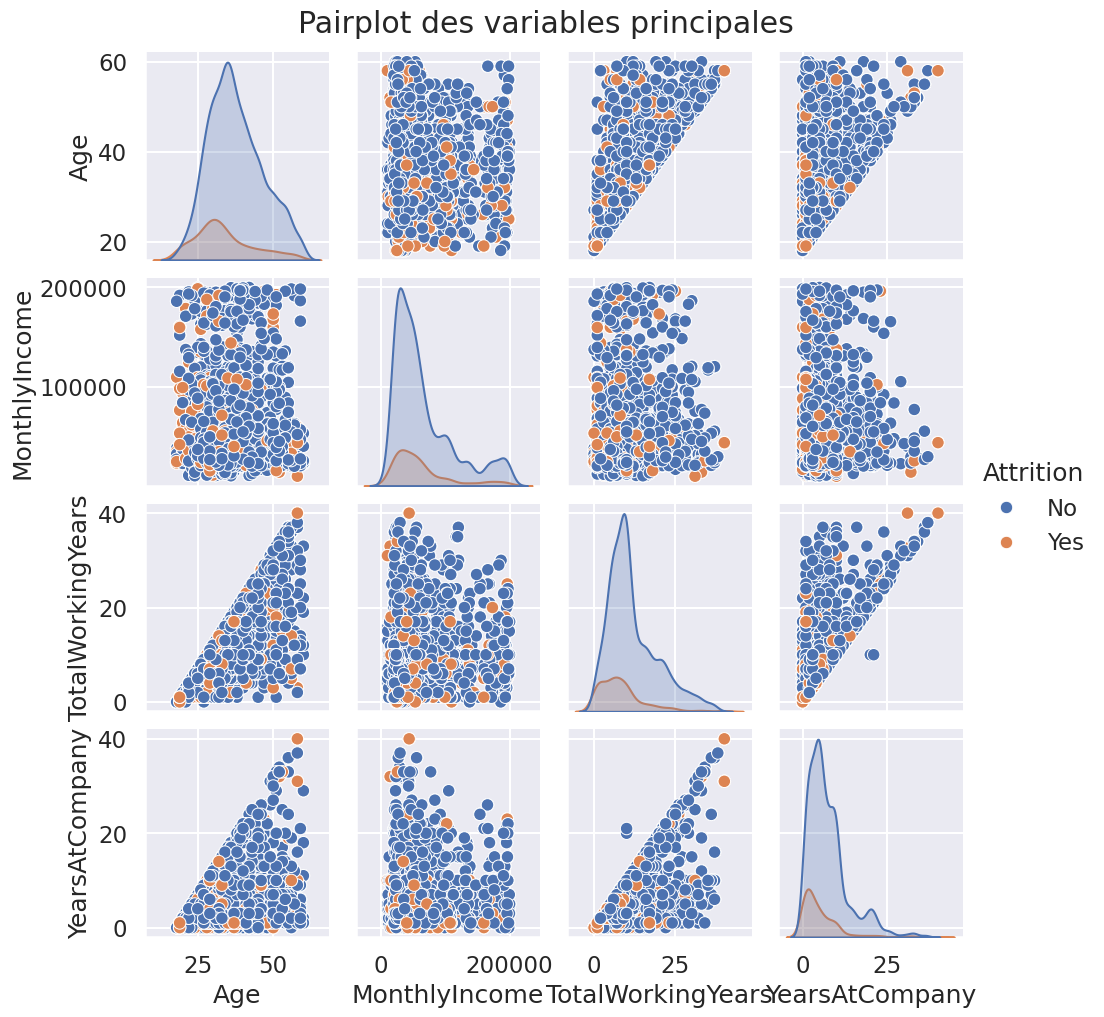

In [18]:
# Matrice de corrélation
plt.figure(figsize=(15, 10))
# On ne garde que les colonnes numériques pour la corrélation
numeric_df = merged_data.select_dtypes(include=['number'])
# On retire EmployeeID car c'est un index technique
if 'EmployeeID' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['EmployeeID'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation (avant encodage)')
plt.show()

# Pairplot pour les variables principales
# On sélectionne quelques variables clés pour éviter un graphique trop chargé
main_vars = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'Attrition']
# On vérifie si les colonnes existent
existing_vars = [v for v in main_vars if v in merged_data.columns]

if len(existing_vars) > 1:
    sns.pairplot(merged_data[existing_vars], hue='Attrition', diag_kind='kde')
    plt.suptitle('Pairplot des variables principales', y=1.02)
    plt.show()

Numérisation du dataset

In [19]:
# Copie de sécurité
data_to_encode = merged_data.copy()

# Colonnes d'heures à conserver en format heure (HH:MM:SS), sans One-Hot
time_cols = ['Mean_In_Time', 'Mean_Out_Time']

# Colonnes catégorielles hors colonnes d'heures
categorical_cols = [
    c for c in data_to_encode.select_dtypes(include=['object', 'category']).columns
    if c not in time_cols
]

# Encodage One-Hot uniquement sur les variables catégorielles
merged_data_encoded = pd.get_dummies(
    data_to_encode,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print('Shape avant encodage :', data_to_encode.shape)
print('Shape après encodage :', merged_data_encoded.shape)
merged_data_encoded.head()

Shape avant encodage : (4410, 32)
Shape après encodage : (4410, 45)


,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,DistanceFromHome,Education,EmployeeCount,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,Mean_In_Time,Mean_Out_Time,Mean_Duration_Hours,Attrition_Yes,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,1,3.00,4.00,2.00,51,6,2,1,1,131160,1.00,11,8,0,1.00,6,1,0,0,3,3,09:59:57,17:19:55,7.33,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,2,3.00,2.00,4.00,31,10,1,1,1,41890,0.00,23,8,1,6.00,3,5,1,4,2,4,09:59:06,17:39:31,7.67,1,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
2,3,2.00,2.00,1.00,32,17,4,1,4,193280,1.00,15,8,3,5.00,2,5,0,3,3,3,10:01:17,17:01:51,7.01,0,1,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0
3,4,4.00,4.00,3.00,38,2,5,1,3,83210,3.00,11,8,3,13.00,5,8,7,5,2,3,09:58:44,17:09:48,7.18,0,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0
4,5,4.00,1.00,3.00,32,10,1,1,1,23420,4.00,12,8,2,9.00,2,6,0,4,3,3,09:59:51,17:59:13,7.99,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1
